# Install & Import

In [1]:
!pip install scikit-learn


In [2]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Dataset

In [4]:
import pandas as pd

file_path =  "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# TF-IDF Vectorization

In [5]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)


# Train Final Model (dengan hyperparameter terbaik)

In [6]:
# Best Params: {'C': 1.0, 'kernel': 'linear', 'gamma': -}

best_C = 1.0
best_kernel = 'linear'

final_model = SVC(
    C=best_C,
    kernel=best_kernel,
    probability=True,
    random_state=42
)

# Combine Train + Validation
X_final = vectorizer.fit_transform(pd.concat([X_train, X_val]))
y_final = pd.concat([y_train, y_val]).values

final_model.fit(X_final, y_final)


SVC(kernel='linear', probability=True, random_state=42)

# Evaluate on Test Set

Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (urutan sesuai encoded label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8834

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.8577    0.9518    0.9023       228
Non-bullying     0.9317    0.8065    0.8646       186

    accuracy                         0.8865       414
   macro avg     0.8947    0.8791    0.8834       414
weighted avg     0.8909    0.8865    0.8853       414



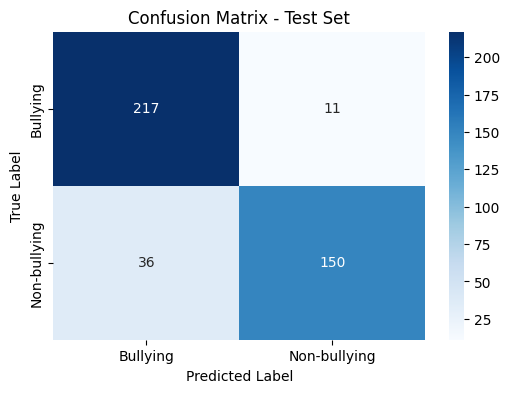

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prediksi ---
# X_test_tfidf was generated with the vectorizer fitted on X_train only.
# The 'vectorizer' object itself was re-fitted on X_train + X_val in the previous cell.
# We need to transform X_test using the current state of the vectorizer.
y_pred = final_model.predict(vectorizer.transform(X_test))

# --- Mapping label biner ---
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

# Urutkan sesuai nilai encoded label
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (urutan sesuai encoded label):")
print(class_names)

# --- Evaluasi ---
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# Classification Report
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [8]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
# Corrected: Transform X_test for benchmarking
X_test_transformed = vectorizer.transform(X_test)
benchmark_size = min(32, X_test_transformed.shape[0]) # Fix: Changed len() to .shape[0]
subset = X_test_transformed[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.004189639091491699
📊 Throughput: 7637.889398393638 samples/sec
